### **[Non-Parametric Regression](https://medium.com/financial-engineering/77ecdaf7c073)**

> LOESS (locally estimated scatterplot smoothing)

In [1]:
import sys

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.width', 1000)
pd.set_option('display.precision', 4)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

%autosave 15

Autosaving every 15 seconds


##### **1. LOAD AND PREPARE THE DATA**

In [2]:
url = 'https://simplified-zone.com/wp-content/uploads/2025/11/M2_data.csv'
data = pd.read_csv(url)
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')

# For this example, we'll model DXY with only X10Y_TBY
dependent_var = 'DXY'
independent_var = 'X10Y_TBY'

data_clean = data[[dependent_var, independent_var]].dropna()

Y = data_clean[dependent_var]
X = data_clean[independent_var]

print(f"Data loaded. Modeling {dependent_var} ~ {independent_var}")
print("-" * 30 + "\n")

Data loaded. Modeling DXY ~ X10Y_TBY
------------------------------



In [3]:
display(data_clean.head(10))

,DXY,X10Y_TBY
Date,,
2016-01-04,0.0024,-0.0106
2016-01-05,0.0054,0.0013
2016-01-06,-0.0022,-0.0316
2016-01-07,-0.0097,-0.0110
2016-01-08,0.0033,-0.0107
2016-01-11,0.0019,0.0131
2016-01-12,0.0024,-0.0259
2016-01-13,-0.0004,-0.0171
2016-01-14,0.0016,0.0155


In [4]:
display(data_clean.describe())

,DXY,X10Y_TBY
count,250.0000,250.0000
mean,0.0002,0.0006
std,0.0048,0.0246
min,-0.0160,-0.0920
25%,-0.0025,-0.0139
50%,-0.0000,0.0003
75%,0.0029,0.0151
max,0.0205,0.1128


In [5]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2016-01-04 to 2016-12-30
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DXY       250 non-null    float64
 1   X10Y_TBY  250 non-null    float64
dtypes: float64(2)
memory usage: 5.9 KB


##### **2. RUN A "BASELINE" OLS MODEL**

In [6]:
X_ols = sm.add_constant(X)
ols_model = sm.OLS(Y, X_ols)
ols_results = ols_model.fit()

# Get the fitted values
ols_preds = ols_results.predict(X_ols)
print("OLS model fit.")
print("-" * 30 + "\n")

OLS model fit.
------------------------------



##### **3. RUN LOESS MODELS**

In [7]:
# statsmodels.nonparametric.lowess returns an array of
# [x_sorted, y_fitted]
# We must sort our data by X for plotting

# First, sort the data
data_sorted = data_clean.sort_values(by=independent_var)
Y_sorted = data_sorted[dependent_var]
X_sorted = data_sorted[independent_var]


# --- Model 1: LOESS (Good Fit) ---
# Let's use a "span" (frac) of 0.3, or 30% of the data
# This is a good starting point
loess_good_fit = sm.nonparametric.lowess(
    Y_sorted, X_sorted, frac=0.3
)
loess_good_Y = loess_good_fit[:, 1] # Get just the Y-fitted values


# --- Model 2: LOESS (Overfit / "Wiggly") ---
# Let's use a tiny "span" (frac) of 0.05, or 5%
loess_overfit = sm.nonparametric.lowess(
    Y_sorted, X_sorted, frac=0.05
)
loess_overfit_Y = loess_overfit[:, 1] # Get just the Y-fitted values

print("LOESS models fit.")
print("-" * 30 + "\n")

LOESS models fit.
------------------------------



##### **4. VISUALIZE THE RESULTS**

Generating plot of OLS vs. LOESS...
This plot shows the 'high-bias' OLS line,
the 'high-variance' wiggly LOESS,
and the 'good-fit' LOESS curve.


--- End of Analysis ---


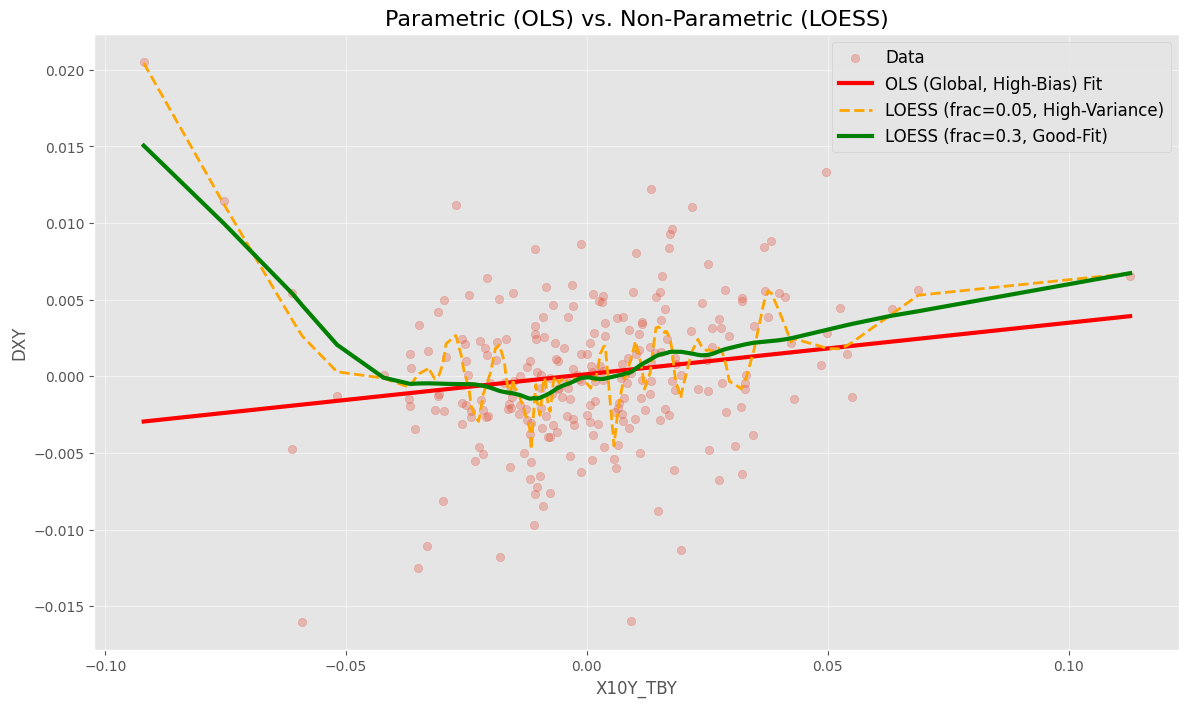

In [8]:
print("Generating plot of OLS vs. LOESS...")

plt.figure(figsize=(14, 8))

# a. The raw data
plt.scatter(X, Y, alpha=0.3, label='Data')

# b. The "bad" OLS line
# (We need to plot it against the sorted X values for a clean line)
ols_preds_sorted = ols_results.predict(sm.add_constant(X_sorted))
plt.plot(X_sorted, ols_preds_sorted, color='red', linewidth=3,
         label='OLS (Global, High-Bias) Fit')

# c. The "too wiggly" LOESS
plt.plot(X_sorted, loess_overfit_Y, color='orange', linewidth=2,
         linestyle='--', label='LOESS (frac=0.05, High-Variance)')

# d. The "just right" LOESS
plt.plot(X_sorted, loess_good_Y, color='green', linewidth=3,
         label='LOESS (frac=0.3, Good-Fit)')

plt.title('Parametric (OLS) vs. Non-Parametric (LOESS)', fontsize=16)
plt.xlabel(independent_var, fontsize=12)
plt.ylabel(dependent_var, fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)

# Save the plot to a file
if not IN_COLAB:
  plt.savefig('loess_comparison_plot.png')
  print("\nPlot saved as 'loess_comparison_plot.png'.")
print("This plot shows the 'high-bias' OLS line,")
print("the 'high-variance' wiggly LOESS,")
print("and the 'good-fit' LOESS curve.")
print("\n\n--- End of Analysis ---")